# Task 1 Story: Car Color Classification (DVM)

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('.')
RUN_DIR = ROOT / 'runs_task1_color'
CFG_PATH = ROOT / 'configs' / 'task1_color.yaml'
SUMMARY_PATH = RUN_DIR / 'task1_summary.json'


def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


In [2]:
required_paths = [
    CFG_PATH,
    RUN_DIR,
    SUMMARY_PATH,
    RUN_DIR / 'dataset_split.csv',
]
missing = [p for p in required_paths if not p.exists()]
assert not missing, f'Missing required artifacts: {missing}'
print('Preflight OK')

Preflight OK


 ## 1 EDA

In [3]:
from collections import Counter
from PIL import Image
import numpy as np
import yaml

with CFG_PATH.open('r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

data_root = Path(cfg['data_root'])
front_only = bool(cfg.get('front_only', True))
img_paths = sorted([p for p in data_root.rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}])


def parse_meta(path: Path):
    parts = path.stem.split('$$')
    if len(parts) < 7:
        return None
    color = parts[3].strip().lower()
    try:
        viewpoint = int(parts[6].strip()) if parts[6].strip() else None
    except ValueError:
        viewpoint = None
    if not color:
        return None
    return color, viewpoint

meta = []
for p in img_paths:
    m = parse_meta(p)
    if m is not None:
        meta.append((p, m[0], m[1]))

all_counts = Counter(x[1] for x in meta)
front_meta = [x for x in meta if (x[2] is None or x[2] == 0)]
front_counts = Counter(x[1] for x in front_meta)

print('Total image files:', len(img_paths))
print('Parsed metadata records:', len(meta))
print('Front-view records (viewpoint==0 or missing):', len(front_meta))
print('Unique classes (all):', len(all_counts))
print('Unique classes (front):', len(front_counts))
print('Using front_only from config:', front_only)

pd.DataFrame({
    'class': list(front_counts.keys()),
    'count_front': list(front_counts.values()),
}).sort_values('count_front', ascending=False).head(15)

Total image files: 61827
Parsed metadata records: 61827
Front-view records (viewpoint==0 or missing): 61827
Unique classes (all): 23
Unique classes (front): 23
Using front_only from config: True


,class,count_front
0,black,14317
1,grey,9474
3,white,9395
5,blue,8483
8,silver,7770
4,red,6095
6,unlisted,1516
14,brown,911
11,green,777
7,yellow,667


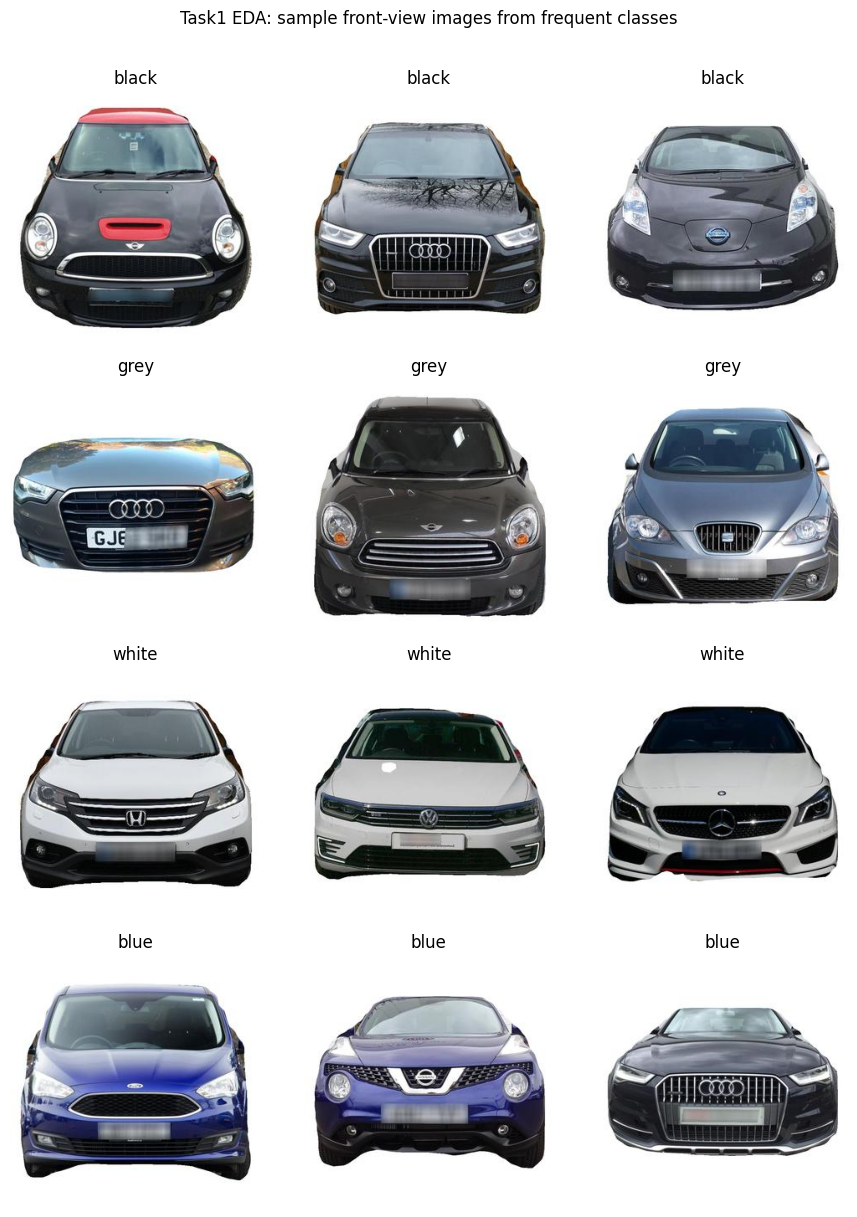

In [4]:
top_classes = [c for c, _ in front_counts.most_common(4)]
vis_pool = {c: [x[0] for x in front_meta if x[1] == c] for c in top_classes}

fig, axes = plt.subplots(len(top_classes), 3, figsize=(9, 3 * len(top_classes)))
if len(top_classes) == 1:
    axes = np.array([axes])

rng = np.random.default_rng(42)
for i, cls in enumerate(top_classes):
    candidates = vis_pool[cls]
    picks = rng.choice(candidates, size=min(3, len(candidates)), replace=False)
    for j in range(3):
        ax = axes[i, j]
        ax.axis('off')
        if j >= len(picks):
            continue
        with Image.open(picks[j]) as im:
            ax.imshow(im.convert('RGB'))
        ax.set_title(f'{cls}')

plt.suptitle('Task1 EDA: sample front-view images from frequent classes', y=1.01)
plt.tight_layout()
plt.show()

## 1) Configuration 

- `custom_resnet18_like_scratch`
- `mobilenet_v3_large_imagenet_finetune`
- `densenet121_imagenet_finetune`

In [5]:
import os
import sys
from pathlib import Path

RUN_TRAIN = False
PYTHON_BIN = Path('venv/bin/python') if Path('venv/bin/python').exists() else Path(sys.executable)
cmd = f'"{PYTHON_BIN}" task1_color_short.py --config configs/task1_color.yaml'

if RUN_TRAIN:
    os.system(cmd)
else:
    print('Training is skipped. Set RUN_TRAIN=True to launch training.')
    print('Command:', cmd)


Training is skipped. Set RUN_TRAIN=True to launch training.
Command: "/Users/kirillkonovalov/Documents/itmo/venv/bin/python" task1_color_short.py --config configs/task1_color.yaml


## 2) Final comparison on test split

We load `task1_summary.json` and inspect F1-macro for each model.

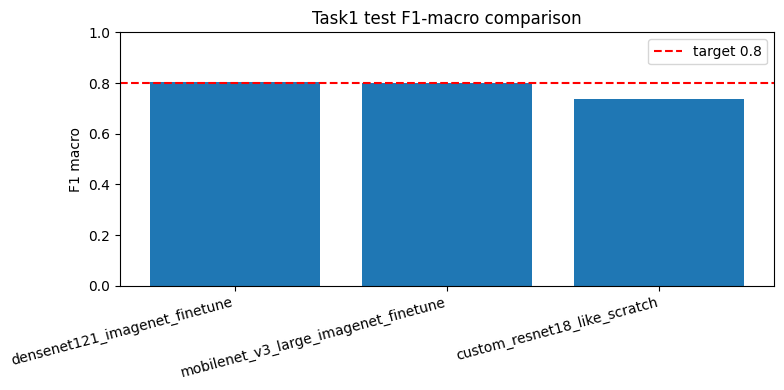

In [6]:
summary = load_json(SUMMARY_PATH)
results = pd.DataFrame(summary['results'])
results = results.sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
results[['model_name', 'best_epoch', 'best_val_f1', 'test_acc', 'test_f1_macro', 'test_loss']]

plt.figure(figsize=(8, 4))
plt.bar(results['model_name'], results['test_f1_macro'])
plt.axhline(0.8, linestyle='--', color='red', label='target 0.8')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1)
plt.ylabel('F1 macro')
plt.title('Task1 test F1-macro comparison')
plt.legend()
plt.tight_layout()
plt.show()

## 3) Training curves per model

Each model has a `history.json` with train/val curves per epoch.

Found histories: 3


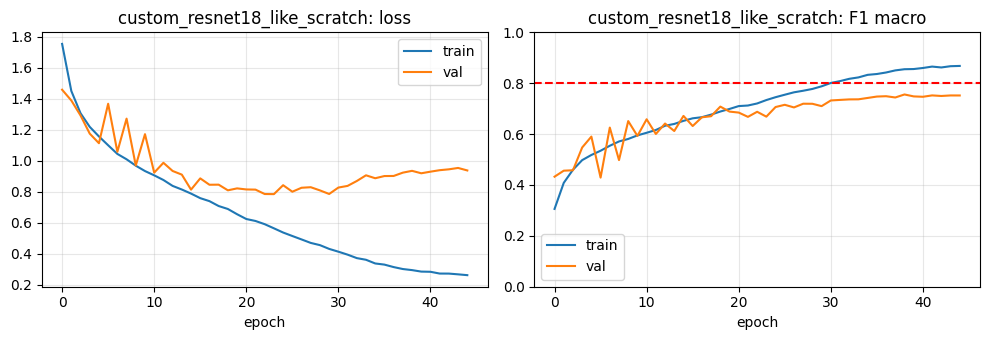

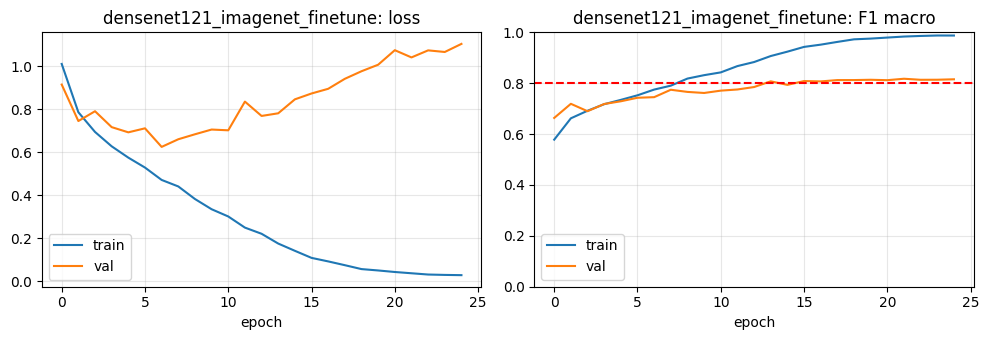

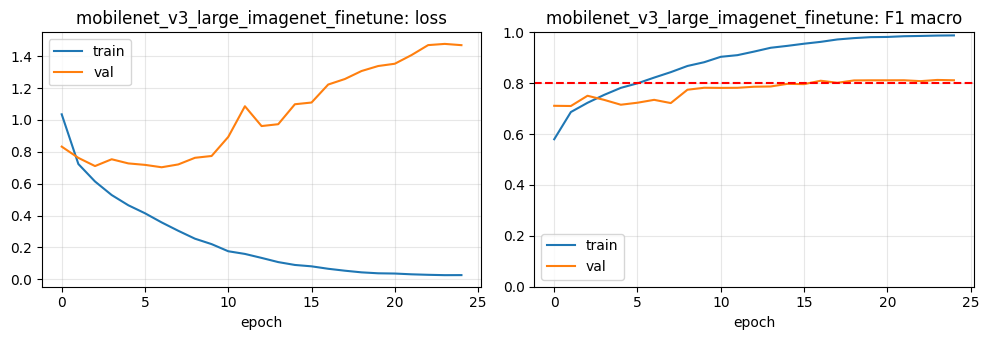

In [7]:
history_paths = sorted(RUN_DIR.glob('*/history.json'))
print('Found histories:', len(history_paths))

for hp in history_paths:
    model_name = hp.parent.name
    h = load_json(hp)
    tr = pd.DataFrame(h['train'])
    va = pd.DataFrame(h['val'])
    n = min(len(tr), len(va))

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(tr['loss'][:n], label='train')
    axes[0].plot(va['loss'][:n], label='val')
    axes[0].set_title(f'{model_name}: loss')
    axes[0].set_xlabel('epoch')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(tr['f1_macro'][:n], label='train')
    axes[1].plot(va['f1_macro'][:n], label='val')
    axes[1].axhline(0.8, linestyle='--', color='red')
    axes[1].set_title(f'{model_name}: F1 macro')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 4) Inference demo


In [8]:
import os
import sys
from pathlib import Path

summary = load_json(SUMMARY_PATH)
best_block = summary.get("best_model", {}) if isinstance(summary, dict) else {}
results = summary.get("results", []) if isinstance(summary, dict) else []

if best_block and best_block.get("model"):
    best_model_name = str(best_block["model"])
elif results:
    best_model_name = sorted(results, key=lambda x: float(x.get("test_f1_macro", 0.0)), reverse=True)[0]["model_name"]
else:
    raise RuntimeError("No model info found in task1_summary.json")

weights_path = Path(str(best_block.get("weights_path", ""))).expanduser()
if not weights_path.is_file():
    weights_path = RUN_DIR / best_model_name / f"best_{best_model_name}.pth"

if not weights_path.is_file():
    raise FileNotFoundError(f"Weights file not found: {weights_path}")

RUN_INFER = True
PYTHON_BIN = Path("venv/bin/python") if Path("venv/bin/python").exists() else Path(sys.executable)
cmd = (
    f"\"{PYTHON_BIN}\" task1_color_inference.py "
    f"--weights \"{weights_path}\" "
    f"--source data/dvm_fronts/confirmed_fronts "
    f"--out_dir runs_task1_color/inference_{best_model_name}"
)

if RUN_INFER:
    ret = os.system(cmd)
    if ret != 0:
        print(f"Inference command failed with exit code {ret}")
else:
    print("Inference is skipped. Set RUN_INFER=True to launch inference.")
    print("Command:", cmd)


Abarth$$595$$2013$$Black$$2_4$$100$$image_1.jpg	black	0.9999
Abarth$$595$$2013$$Black$$2_4$$191$$image_0.jpg	black	0.8570
Abarth$$595$$2013$$Black$$2_4$$229$$image_2.jpg	black	0.9926
Abarth$$595$$2013$$Black$$2_4$$236$$image_2.jpg	black	0.9941
Abarth$$595$$2013$$Black$$2_4$$287$$image_5.jpg	black	0.9973
Abarth$$595$$2013$$Grey$$2_4$$193$$image_2.jpg	grey	0.9997
Abarth$$595$$2013$$Grey$$2_4$$238$$image_2.jpg	grey	0.8823
Abarth$$595$$2013$$Grey$$2_4$$71$$image_1.jpg	grey	0.9884
Abarth$$595$$2013$$Grey$$2_4$$75$$image_3.jpg	grey	1.0000
Abarth$$595$$2013$$Multicolour$$2_4$$63$$image_2.jpg	red	0.9715
Abarth$$595$$2013$$Multicolour$$2_4$$63$$image_3.jpg	grey	0.8848
Abarth$$595$$2013$$White$$2_4$$155$$image_7.jpg	white	0.9981
Abarth$$595$$2013$$White$$2_4$$172$$image_0.jpg	white	0.9727
Abarth$$595$$2013$$White$$2_4$$231$$image_3.jpg	white	0.9992
Abarth$$595$$2013$$White$$2_4$$41$$image_6.jpg	white	0.9988
Abarth$$595$$2014$$Black$$2_4$$107$$image_6.jpg	black	0.9972
Abarth$$595$$2014$$Black$$2_

Traceback (most recent call last):
  File "/Users/kirillkonovalov/Documents/itmo/task1_git_folder/Computer-Vision-lab1/task1_color_inference.py", line 197, in <module>
    main()
    ~~~~^^
  File "/Users/kirillkonovalov/Documents/itmo/task1_git_folder/Computer-Vision-lab1/task1_color_inference.py", line 171, in main
    probs = torch.softmax(model(x), dim=1)[0].detach().cpu()
                          ~~~~~^^^
  File "/Users/kirillkonovalov/Documents/itmo/venv/lib/python3.14/site-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/kirillkonovalov/Documents/itmo/venv/lib/python3.14/site-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
  File "/Users/kirillkonovalov/Documents/itmo/venv/lib/python3.14/site-packages/torchvision/models/densenet.py", line 213, in forward
    features = self.features(x)
  File "/Users

Inference command failed with exit code 2


## 5) Prediction vs true labels (model comparison)

This section runs all trained Task1 models on random test images and compares predictions against ground truth labels.

,image,gt,pred_densenet121_imagenet_finetune,ok_densenet121_imagenet_finetune,pred_mobilenet_v3_large_imagenet_finetune,ok_mobilenet_v3_large_imagenet_finetune,pred_custom_resnet18_like_scratch,ok_custom_resnet18_like_scratch
0,BMW$$X5$$2015$$Grey$$8_39$$840$$image_1.jpg,grey,grey,1,grey,1,grey,1
1,Audi$$TTS$$2016$$White$$7_48$$59$$image_9.jpg,white,white,1,white,1,white,1
2,Volvo$$XC60$$2016$$Grey$$96_16$$665$$image_13.jpg,grey,grey,1,grey,1,unlisted,0
3,Ford$$C-Max$$2013$$Red$$29_2$$884$$image_2.jpg,red,red,1,red,1,red,1
4,Volkswagen$$Touareg$$2016$$White$$95_28$$114$$...,white,white,1,white,1,white,1
5,Peugeot$$3008$$2012$$Black$$69_13$$127$$image_...,black,black,1,black,1,black,1
6,Audi$$RS4 Avant$$2015$$Grey$$7_27$$82$$image_5...,grey,grey,1,grey,1,grey,1
7,BMW$$1 Series$$2009$$Black$$8_1$$583$$image_10...,black,black,1,black,1,black,1
8,Porsche$$Macan$$2017$$Unlisted$$71_10$$447$$im...,unlisted,black,0,black,0,black,0
9,BMW$$1 Series$$2007$$Black$$8_1$$248$$image_0.jpg,black,black,1,black,1,grey,0


Per-model accuracy on this random sample:


,model,sample_acc
0,densenet121_imagenet_finetune,0.916667
1,mobilenet_v3_large_imagenet_finetune,0.916667
2,custom_resnet18_like_scratch,0.750000


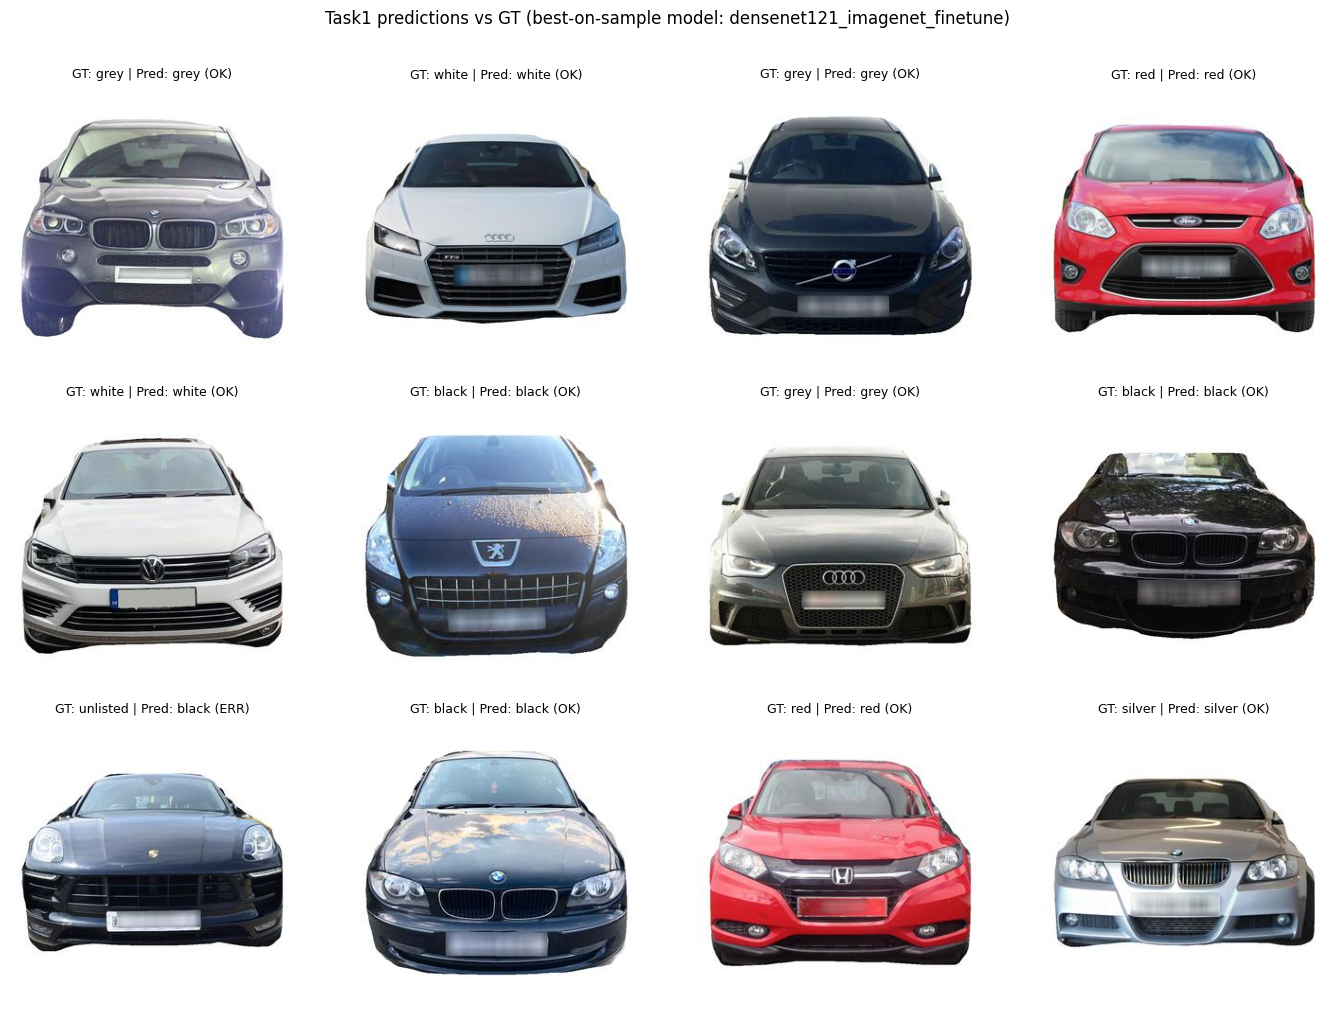

In [9]:
from PIL import Image
import yaml
import importlib
import dvm_color_classification as dvmcc

dvmcc = importlib.reload(dvmcc)
class_names_from_split_csv = dvmcc.class_names_from_split_csv
predict_task1_models_on_paths = dvmcc.predict_task1_models_on_paths

split_csv = RUN_DIR / 'dataset_split.csv'
test_df = pd.read_csv(split_csv)
test_df = test_df[test_df['split'] == 'test'].copy()
test_df['color'] = test_df['color'].astype(str).str.lower()
class_names = class_names_from_split_csv(split_csv, split='test')

summary = load_json(SUMMARY_PATH)
ranked = [r.get('model_name') for r in summary.get('results', []) if r.get('model_name')]

checkpoints = {}
for m in ranked:
    ckpt = RUN_DIR / m / f'best_{m}.pth'
    if ckpt.exists():
        checkpoints[m] = ckpt

if not checkpoints:
    for ckpt in sorted(RUN_DIR.glob('*/best_*.pth')):
        checkpoints[ckpt.parent.name] = ckpt

assert checkpoints, f'No model checkpoints found under {RUN_DIR}'

sample_n = min(12, len(test_df))
sample_df = test_df.sample(n=sample_n, random_state=42).reset_index(drop=True)

with CFG_PATH.open('r', encoding='utf-8') as f:
    cfg_local = yaml.safe_load(f)
preds_by_model = predict_task1_models_on_paths(
    checkpoints=checkpoints,
    class_names=class_names,
    image_paths=sample_df['img_path'].tolist(),
    img_size=int(cfg_local['img_size']),
    device='cpu',
)

rows = []
for i, row in sample_df.iterrows():
    item = {
        'image': Path(row['img_path']).name,
        'gt': row['color'],
    }
    for m in checkpoints:
        pred = preds_by_model[m][i]
        item[f'pred_{m}'] = pred
        item[f'ok_{m}'] = int(pred == row['color'])
    rows.append(item)

comp_df = pd.DataFrame(rows)
display(comp_df)

acc_rows = []
for m in checkpoints:
    acc_rows.append({'model': m, 'sample_acc': float(np.mean(comp_df[f'ok_{m}']))})
acc_df = pd.DataFrame(acc_rows).sort_values('sample_acc', ascending=False)
print('Per-model accuracy on this random sample:')
display(acc_df)

best_model = acc_df.iloc[0]['model']
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.reshape(-1)
for ax, i in zip(axes, range(sample_n)):
    row = sample_df.iloc[i]
    p = Path(row['img_path'])
    with Image.open(p) as im:
        ax.imshow(im.convert('RGB'))
    pred = preds_by_model[best_model][i]
    mark = 'OK' if pred == row['color'] else 'ERR'
    ax.set_title(f"GT: {row['color']} | Pred: {pred} ({mark})", fontsize=9)
    ax.axis('off')

for i in range(sample_n, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Task1 predictions vs GT (best-on-sample model: {best_model})', y=1.01)
plt.tight_layout()
plt.show()

## 6) Error analysis: wrong predictions

Show several incorrect predictions of the best Task1 model (highest test F1-macro).

Found 182 wrong predictions out of 2000 evaluated samples.
Showing most confident mistakes (hard errors):


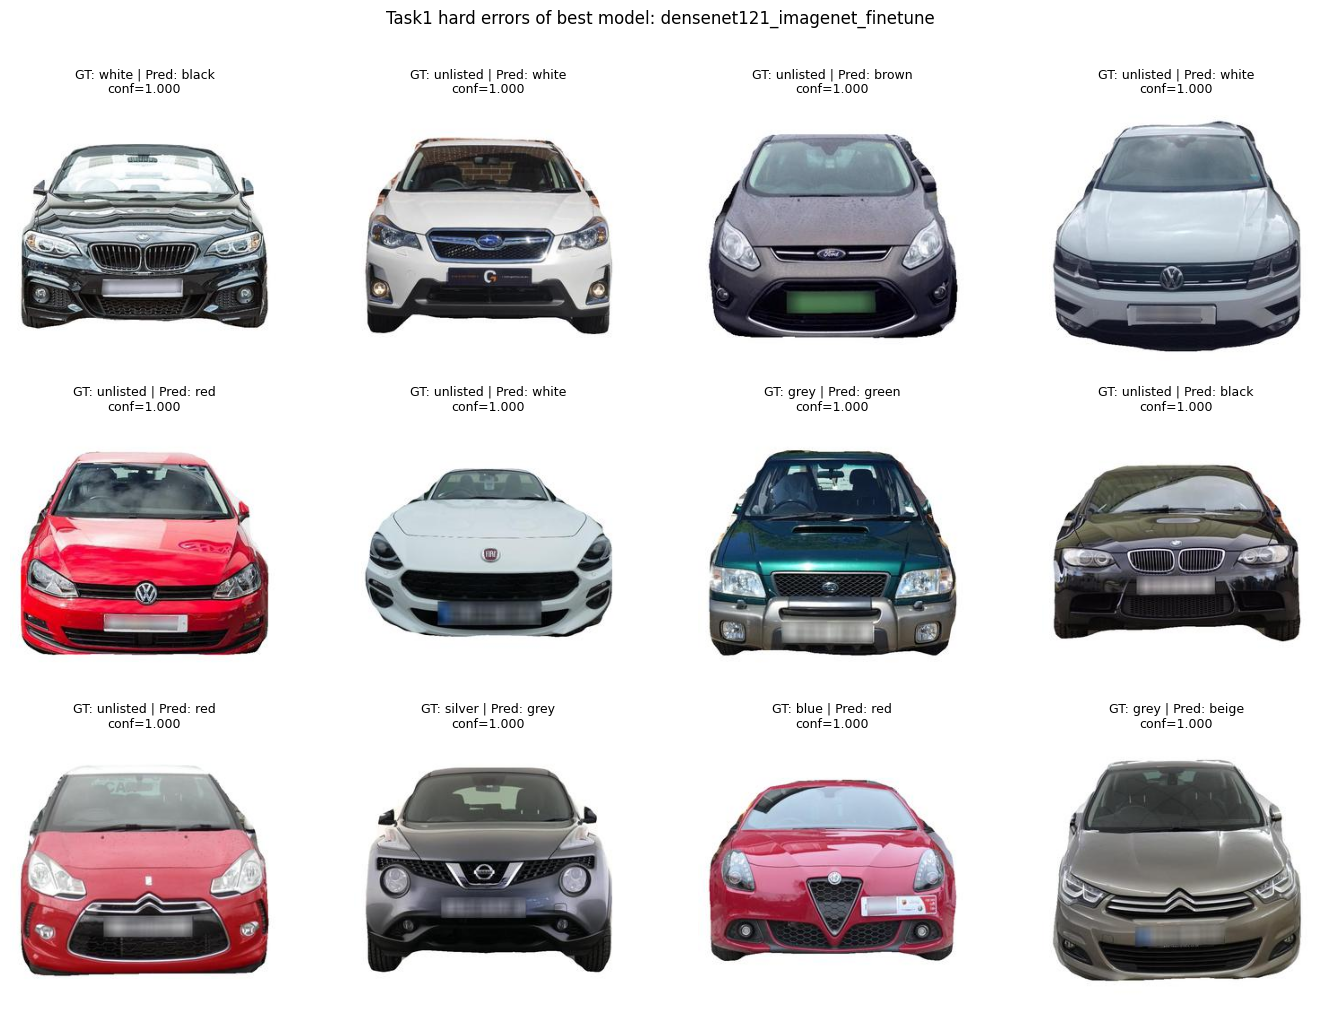

In [11]:
import yaml
import torch
import torchvision.transforms as T

summary = load_json(SUMMARY_PATH)
results = summary.get('results', [])
best = sorted(results, key=lambda x: x.get('test_f1_macro', 0.0), reverse=True)[0]
best_model = best['model_name']
ckpt_path = RUN_DIR / best_model / f'best_{best_model}.pth'

split_csv = RUN_DIR / 'dataset_split.csv'
test_df = pd.read_csv(split_csv)
test_df = test_df[test_df['split'] == 'test'].copy()
test_df['color'] = test_df['color'].astype(str).str.lower()

class_names = sorted(test_df['color'].unique().tolist())
idx_to_class = {i: c for i, c in enumerate(class_names)}

model_builders = {
    'custom_resnet18_like_scratch': lambda n: CustomResNet18Like(num_classes=n),
    'mobilenet_v3_large_imagenet_finetune': dvmcc.build_mobilenet_v3_large,
    'densenet121_imagenet_finetune': dvmcc.build_densenet121,
}

with CFG_PATH.open('r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

model = model_builders[best_model](len(class_names))
ckpt = torch.load(ckpt_path, map_location='cpu')
state = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
model.load_state_dict(state)
model.eval()

eval_tf = T.Compose([
    T.Resize((int(cfg['img_size']), int(cfg['img_size']))),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

max_eval = min(2000, len(test_df))
eval_df = test_df.sample(n=max_eval, random_state=123).reset_index(drop=True)

wrong = []
for _, row in eval_df.iterrows():
    p = Path(row['img_path'])
    if not p.exists():
        continue
    with Image.open(p) as im:
        x = eval_tf(im.convert('RGB')).unsqueeze(0)
    with torch.inference_mode():
        probs = torch.softmax(model(x), dim=1)[0].detach().cpu().numpy()
    pred_idx = int(np.argmax(probs))
    pred_name = idx_to_class.get(pred_idx, f'class_{pred_idx}')
    conf = float(probs[pred_idx])
    gt_name = str(row['color'])
    if pred_name != gt_name:
        wrong.append({
            'path': p,
            'gt': gt_name,
            'pred': pred_name,
            'conf': conf,
        })

wrong = sorted(wrong, key=lambda z: z['conf'], reverse=True)
print(f'Found {len(wrong)} wrong predictions out of {max_eval} evaluated samples.')
print('Showing most confident mistakes (hard errors):')

show_n = min(12, len(wrong))
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.reshape(-1)
for ax, item in zip(axes, wrong[:show_n]):
    with Image.open(item['path']) as im:
        ax.imshow(im.convert('RGB'))
    ax.set_title(
        f"GT: {item['gt']} | Pred: {item['pred']}\nconf={item['conf']:.3f}",
        fontsize=9,
    )
    ax.axis('off')

for i in range(show_n, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Task1 hard errors of best model: {best_model}', y=1.01)
plt.tight_layout()
plt.show()

## 7) Confusion matrices 

Confusion matrices found: 3


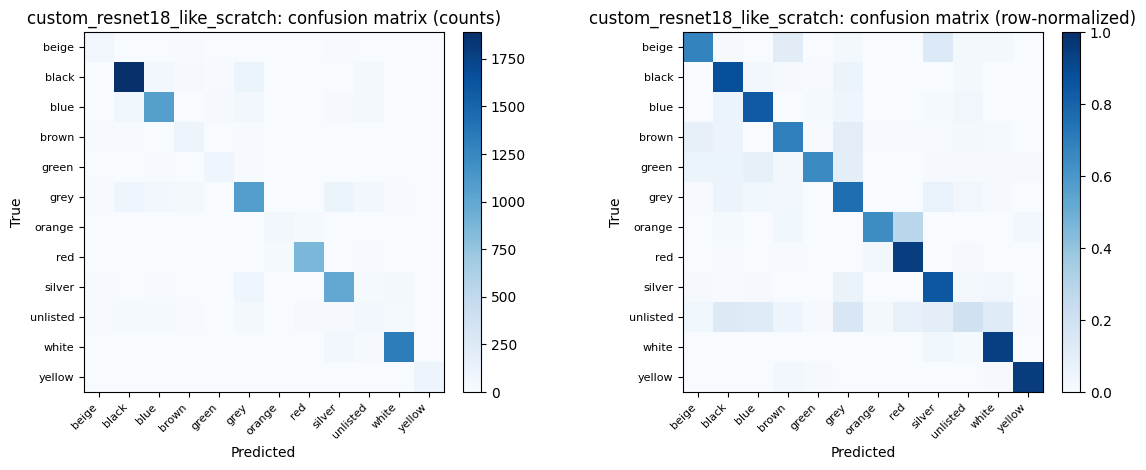

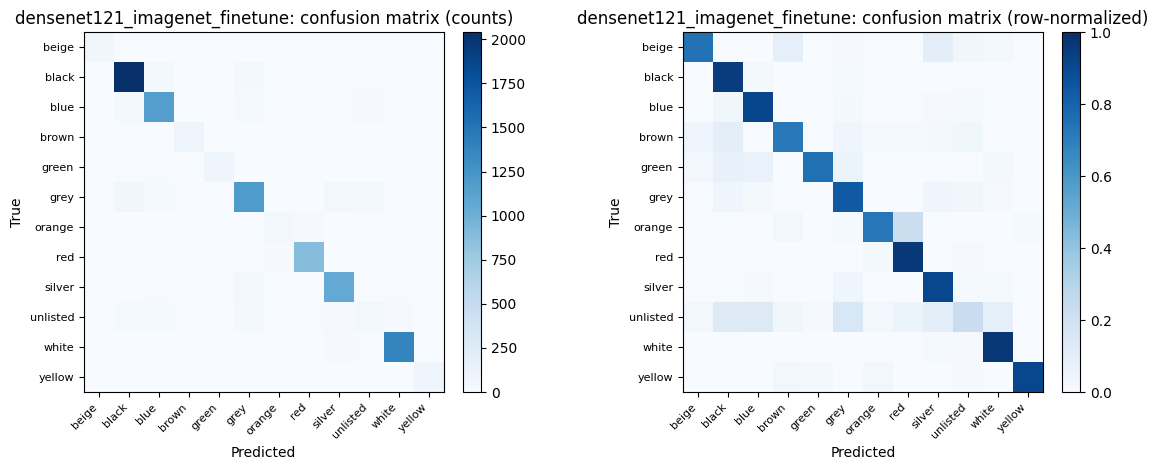

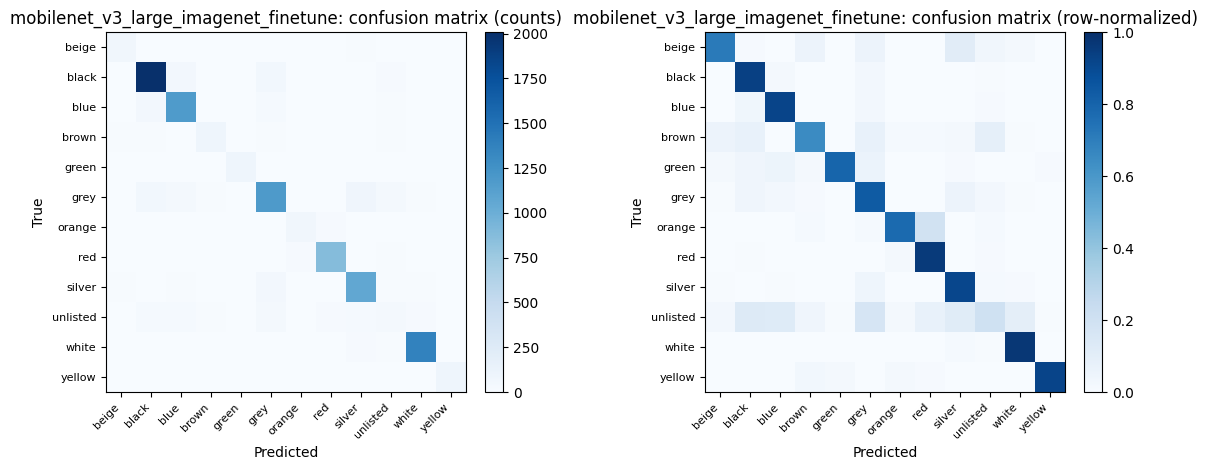

In [12]:
import numpy as np

cm_paths = sorted(RUN_DIR.glob('*/confusion_matrix.csv'))
print('Confusion matrices found:', len(cm_paths))

split_csv = RUN_DIR / 'dataset_split.csv'
if split_csv.exists():
    split_df = pd.read_csv(split_csv)
    class_labels = sorted(split_df['color'].astype(str).str.lower().unique().tolist())
else:
    class_labels = None

if not cm_paths:
    print('No confusion_matrix.csv files found. Run Task1 training with save_confusion=true.')

for cm_path in cm_paths:
    model_name = cm_path.parent.name
    cm = pd.read_csv(cm_path, header=None).values.astype(float)

    if cm.size == 0:
        continue

    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, np.maximum(row_sum, 1.0))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

    im0 = axes[0].imshow(cm, cmap='Blues')
    axes[0].set_title(f'{model_name}: confusion matrix (counts)')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(cm_norm, cmap='Blues', vmin=0.0, vmax=1.0)
    axes[1].set_title(f'{model_name}: confusion matrix (row-normalized)')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        if class_labels and len(class_labels) == cm.shape[0]:
            ticks = np.arange(len(class_labels))
            ax.set_xticks(ticks)
            ax.set_yticks(ticks)
            ax.set_xticklabels(class_labels, rotation=45, ha='right', fontsize=8)
            ax.set_yticklabels(class_labels, fontsize=8)

    plt.tight_layout()
    plt.show()